**PROJECT 3: Gradient Descent Visualization**

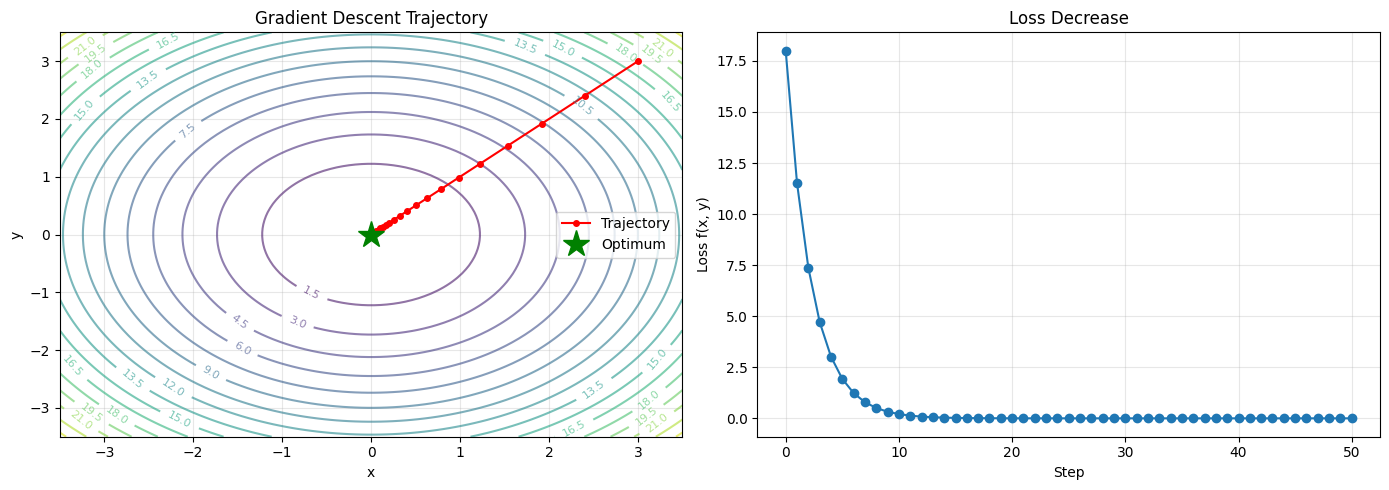

Final point: [4.281743e-05 4.281743e-05]
Final loss: 0.000000


In [1]:
import jax
import jax.numpy as jnp
from jax import grad
import matplotlib.pyplot as plt

# Simple quadratic function: f(x, y) = x^2 + y^2
def f(xy):
    x, y = xy
    return x**2 + y**2

grad_f = grad(f)

# Gradient descent optimization
x0 = jnp.array([3.0, 3.0])
learning_rate = 0.1
n_steps = 50

trajectory = [x0]
losses = [float(f(x0))]

x = x0
for step in range(n_steps):
    gradient = grad_f(x)
    x = x - learning_rate * gradient
    trajectory.append(x)
    losses.append(float(f(x)))

trajectory = jnp.array(trajectory)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2D contour plot
ax = axes[0]
x_range = jnp.linspace(-3.5, 3.5, 100)
y_range = jnp.linspace(-3.5, 3.5, 100)
X, Y = jnp.meshgrid(x_range, y_range)
Z = X**2 + Y**2

contour = ax.contour(X, Y, Z, levels=20, alpha=0.6)
ax.clabel(contour, inline=True, fontsize=8)
ax.plot(trajectory[:, 0], trajectory[:, 1], 'ro-', markersize=4, label='Trajectory')
ax.plot(0, 0, 'g*', markersize=20, label='Optimum')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Gradient Descent Trajectory')
ax.legend()
ax.grid(True, alpha=0.3)

# Loss over time
ax = axes[1]
ax.plot(losses, marker='o')
ax.set_xlabel('Step')
ax.set_ylabel('Loss f(x, y)')
ax.set_title('Loss Decrease')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_descent_visualization.png')
plt.show()

print(f"Final point: {trajectory[-1]}")
print(f"Final loss: {losses[-1]:.6f}")